In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad

import time

## Basic Overview
We are trying to solve the Allen-Cahn equation, but not numerically. We will try to see if a **Neural Network** can just learn the solution ϕ(x,t) directly.

### 1) Defining the Neural Network
We are defining the brain of our PINN (Physics Informed Neural Network) the neural network that will take a point (x,t) and output a predicted phase field value ϕ^​. 

Think of it as building a mathematical function approximator whose internal parameters (weights and biases) will be tuned later during training of the NN.

In [4]:
class PINN(nn.Module):
    def __init__(self, layers):     #__init__ is a constructor method that initializes NN architecture.  
        #self is specific instance of class
        #Layers store number of neurons in each layer, including input and output

        super(PINN, self).__init__() #super() refers to parent class (nn.Module) and allows us to call its methods.
        #Helps pytorch to track parameters.
        
        self.network = nn.Sequential() #attribute to hold layers in a sequence.

        for i in range(len(layers) - 1):      #1 less pair than no. of. layers
            self.network.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i+1]))   #adds a layer to nn.Sequential container
            #computes y = xA^T + b, where A is weight matrix and b is bias vector
            #For nn.Linear(2,64) takes 2 inputs (x,t), produces 64 neurons 

            if i < len(layers) - 2:     #No activation after last layer
                self.network.add_module(f"tanh_{i}", nn.Tanh())     #Add Tanh activation function after each hidden layer, outputs (-1, 1), helps model learn complex patterns.
    

    def forward(self, x, t):         #forward (special pytorch method) defines how data flows thorugh network

        inputs = torch.cat([x, t], dim=1)  # shape (N, 2), inputs x and t are concatenated along (column) feature dimension (dim=1)
        return self.network(inputs)         # shape:(N, 1), passes concatenated inputs through the network to produce output .

device = torch.device("cpu")

layers = [2, 64, 64, 64, 64, 1]   #input size 2 (x,t), 4 hidden layers with 64 neurons each, output size 1 (ϕ)
model = PINN(layers).to(device)

print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")
#model.parameters() returns an iterator over all learnable tensors (weights and biases) in the network
#p.numel() no. of. elements in each parameter tensor, sum() gives total count of trainable parameters in the model.

PINN(
  (network): Sequential(
    (linear_0): Linear(in_features=2, out_features=64, bias=True)
    (tanh_0): Tanh()
    (linear_1): Linear(in_features=64, out_features=64, bias=True)
    (tanh_1): Tanh()
    (linear_2): Linear(in_features=64, out_features=64, bias=True)
    (tanh_2): Tanh()
    (linear_3): Linear(in_features=64, out_features=64, bias=True)
    (tanh_3): Tanh()
    (linear_4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 12737


## 2) Physics Informed Loss Function
For now the network exists but outputs garbage, basically random weights mean random predictions. 
We have to train it without any data. So what do we target to minimize?
We minimize how badly the network's output violates the Allen-Cahn equation. 
If ϕ​^ is the actual solution, then when you plug it into the PDE the result should be exactly zero everywhere. 
Any deviation from zero is our needed error.

Ww will have 3 error components:
1) PDE Residual loss (PDE) - Sample random (x,t) points inside the domain, then we compute first compute ∂ϕ^/∂t and ∂^2(ϕ^)/∂x^2. 
Putting these into AC equation we can check how far is it from zero.
2) Initial Condition Loss (ICL) -  At t=0, we know what ϕ should look like (for now its a sinusoidal ). Our network should match this perfectly (ideally), error is the mismatch between them.
3) In Boundary Condition Loss (BCL) - At the edges of the domain we will enforce Neumann boundary conditions. 
Basically the spatial derivative at the walls is zero.

In [5]:
def compute_loss(model, x_pde, t_pde, x_ic, t_ic, phi_ic, x_bc, t_bc):
    #1- PDE residual loss
    x_pde.requires_grad_(True)    #tracks tensors  
    t_pde.requires_grad_(True)
    phi = model(x_pde, t_pde) #(N_pde, 1) 
    
    #first derivatives
    phi_t = grad(phi, t_pde, grad_outputs=torch.ones_like(phi), create_graph=True)[0]  #tuple
    phi_x = grad(phi, x_pde, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    
    # Second derivative
    phi_xx = grad(phi_x, x_pde, grad_outputs=torch.ones_like(phi_x), create_graph=True)[0]
    
    # AC residual:dφ/dt - M*(ε²*φ_xx - (φ³ - φ)) = 0
    M = 1.0  #interface mobility, 1 for simplicity
    eps=0.1   #smaller -> sharper interface between phases
    residual = phi_t - (M * (eps**2 * phi_xx - (phi**3 - phi)))   # Any non zero value can be thought of as a physics violation
    lPDE = torch.mean(residual**2)
    
    # 2 - Initial condition loss
    phi_ic_pred = model(x_ic, t_ic)
    lIC = torch.mean((phi_ic_pred - phi_ic)**2)   #average for standard MSE loss
    
    #3 - Boundary condition loss (Neumann: dφ/dx = 0 at x=0 and x=1)
    x_bc.requires_grad_(True)    #again enabling tracking
    phi_bc = model(x_bc, t_bc)  
    phi_bc_x  = grad(phi_bc, x_bc, grad_outputs=torch.ones_like(phi_bc), create_graph=True)[0]
    lBC=torch.mean(phi_bc_x**2)  #0, is Neumann boundary condition is satisfied    
    
    #Total Loss (sum of all 3)
    totalLoss = lPDE + 50 * lIC + lBC 
    return totalLoss, lPDE, lIC, lBC

In [6]:
#Domain parameters
N_pde = 10000  #interior collocation points
N_ic  = 1000 #initial condition points
N_bc  = 500 #boundary points (250 per side)

x_pde = torch.rand(N_pde, 1)  #PDE points, random (x,t) in domain. x ∈ [0, 1]
t_pde = torch.rand(N_pde, 1) #t ∈ [0, 1]

# Initial condition points: t = 0, φ(x,0) = 0.05*sin(2πx)
x_ic  = torch.rand(N_ic, 1)
t_ic  = torch.zeros(N_ic, 1) # t= 0
phi_ic = 0.1 * torch.sin(2 * torch.pi * x_ic)  #known initial profile

#boundary points: x = 0 and x = 1
t_bc_vals = torch.rand(N_bc, 1)
x_left    = torch.zeros(N_bc // 2, 1)
x_right   = torch.ones(N_bc // 2, 1)
x_bc      = torch.cat([x_left, x_right], dim=0)
t_bc      = torch.cat([t_bc_vals[:N_bc//2], t_bc_vals[N_bc//2:]], dim=0)

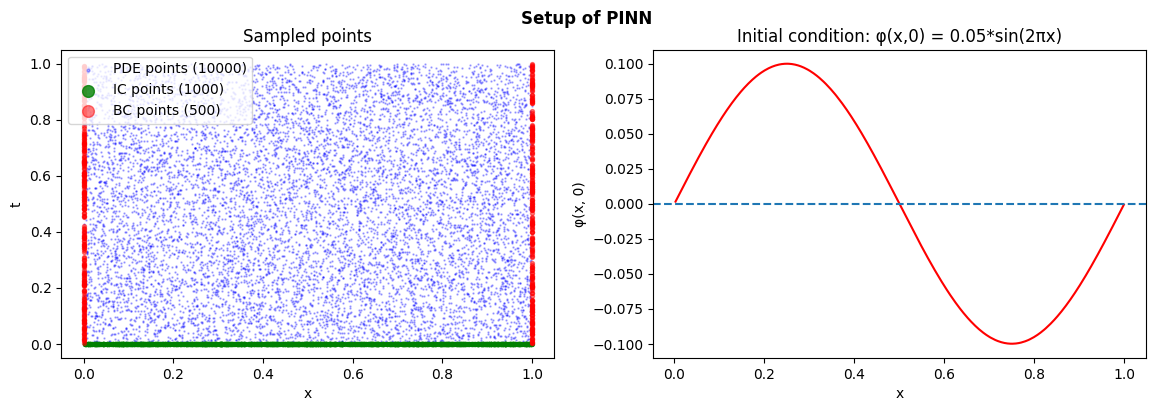

In [7]:
#Visualize the setup of PINN
fig, axes = plt.subplots(1,2, figsize=(14, 4))
fig.suptitle("Setup of PINN", fontweight='bold')

#1: Collocation points in (x,t) domain
ax1 = axes[0]
ax1.scatter(x_pde.detach().numpy(), t_pde.detach().numpy(),
            s=0.5, color='blue', alpha=0.3, label=f'PDE points ({N_pde})')
ax1.scatter(x_ic.detach().numpy(), t_ic.detach().numpy(),
            s=8, color='green', alpha=0.8, label=f'IC points ({N_ic})')
ax1.scatter(x_bc.detach().numpy(), t_bc.detach().numpy(),
            s=8, color='red', alpha=0.5, label=f'BC points ({N_bc})')
ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_title("Sampled points")
ax1.legend(markerscale=3)

#Initial condition profile φ(x,0)
ax2 = axes[1]
x_plot = x_ic.detach().numpy()
phi_plot = phi_ic.detach().numpy()
sorted_idx = x_plot[:, 0].argsort()
ax2.plot(x_plot[sorted_idx], phi_plot[sorted_idx], color='red')
ax2.axhline(0,linestyle='--')
ax2.set_xlabel("x")
ax2.set_ylabel("φ(x, 0)")
ax2.set_title("Initial condition: φ(x,0) = 0.05*sin(2πx)")

plt.show()

# Coming to training our PINN

Now we run the training loop. The optimizer will repeatedly call `compute_loss()`, and update the weights to reduce this loss. 

By the end, the network will have learned to approximate $\phi(x, t)$ purely from physics.

In [8]:
#Hyperparameters 
epochs_adam  = 10000    #no. of times Adam updates weights, more epochs -> better convergence but longer training time
lr_adam      = 1e-3    #learning rate, how big each weight update step is, smaller - stable, slower convergence; larger - faster, risk of overshooting minima

In [9]:
# Adam (Adaptive movement estimation) optimizer finds gradient of loss for each weight. Then it adapts the step size individually for each weight based on how that weight changed historically.
optimizer = optim.Adam(model.parameters(), lr=lr_adam)     
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9995)

history = {"total": [], "pde": [], "ic": [], "bc": []} #dictionary to store loss history(for later visualizing)

# training Loop
print("Adam training.....")
start = time.time()

for epoch in range(epochs_adam):
    optimizer.zero_grad()
    totalLoss, lPDE, lIC, lBC = compute_loss(model, x_pde, t_pde, x_ic, t_ic, phi_ic, x_bc, t_bc) 
    totalLoss.backward()   #backpropagation computes gradients of totalLoss w.r.t. all learnable parameters in the model and stores them in .grad attribute of each parameter tensor. 
    optimizer.step() #updates weights
    scheduler.step()
    
    history["total"].append(totalLoss.item())   #item() converts PyTorch tensor to float for logging
    history["pde"].append(lPDE.item())  
    history["ic"].append(lIC.item())
    history["bc"].append(lBC.item())

print(f"\nAdam done in {time.time() - start:.1f}s")

Adam training.....

Adam done in 719.2s


## Analysis
Adam looks at the slope, can go downhill quickly. But it tends to bounce around near the minimum.


L-BFGS fine tuning was explored by me but Adam alone achieved sufficient convergence for this 1D case.
Mainly differnece being, L-BFGS looks at both slope and how slope changes. So it can jump much closer to the minimum in less steps. Iterations are slow but precise.

But by actually implementing them, I found out Adam overall does the heavy lifting and gets us about 95% of the way there.

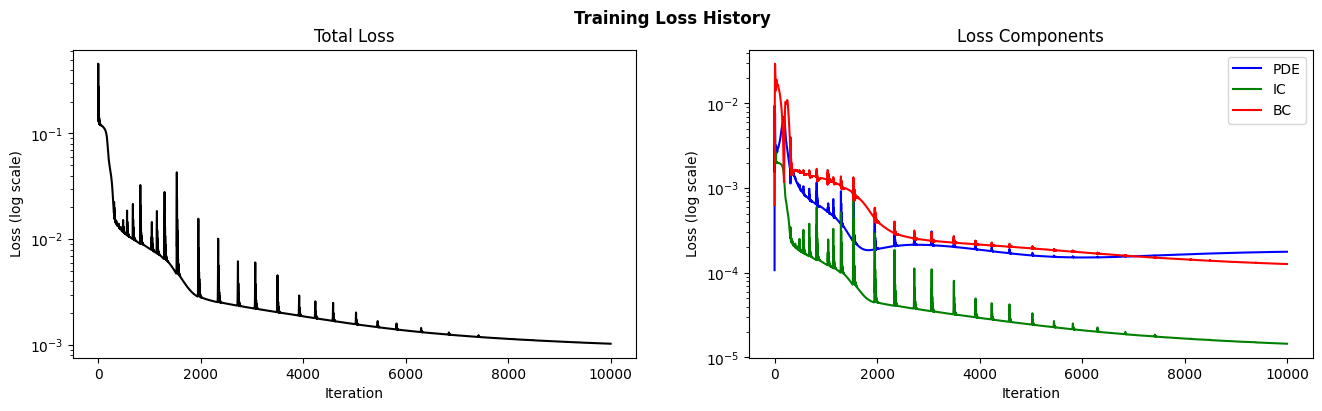

In [10]:
# Ploting Loss
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Training Loss History", fontweight='bold')

epochs_total = range(len(history["total"]))

axes[0].semilogy(epochs_total, history["total"], color='black', linewidth=1.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss (log scale)")
axes[0].set_title("Total Loss")

axes[1].semilogy(epochs_total, history["pde"], label='PDE', color='blue')
axes[1].semilogy(epochs_total, history["ic"],  label='IC',  color='green')
axes[1].semilogy(epochs_total, history["bc"], label='BC',   color='red')
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss (log scale)")
axes[1].set_title("Loss Components")
axes[1].legend()

plt.show()

The total loss decreases steadily over 10000 iterations, dropping nearly an order of magnitude ~10^(⁻4). 
The initial roughness is mainly due to less damping of gamma, which slowly resolves itself. 
Returning a reliable reuslt.

Competing gradient between three loss terms explains the non monotonic behaviour in individual components.
While the total loss reduces well throughout.

### Now lets visually predict the solution. To do this we query the trained network across the entire (x,t) domain and plot ϕ^​(x,t) as a heatmap.

The loss just measures how well the network satisfied the three we gave it. It does not guarantee that solution looks like real Allen-Cahn physics.

If we see evolution from sinusoidal initial condition and gradually sharpen to phases (when ϕ equals 1, -1). 

In [11]:
# Generate prediction grid
n_x = 200   # spatial points
n_t = 200   # time points

x_vals = torch.linspace(0, 1, n_x)
t_vals = torch.linspace(0, 1, n_t)

# Create meshgrid
X, T = torch.meshgrid(x_vals, t_vals, indexing='ij')
x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)

#geting predictions from trained model
model.eval()
with torch.no_grad():
    phi_pred = model(x_flat, t_flat)

phi_grid = phi_pred.reshape(n_x, n_t).numpy()

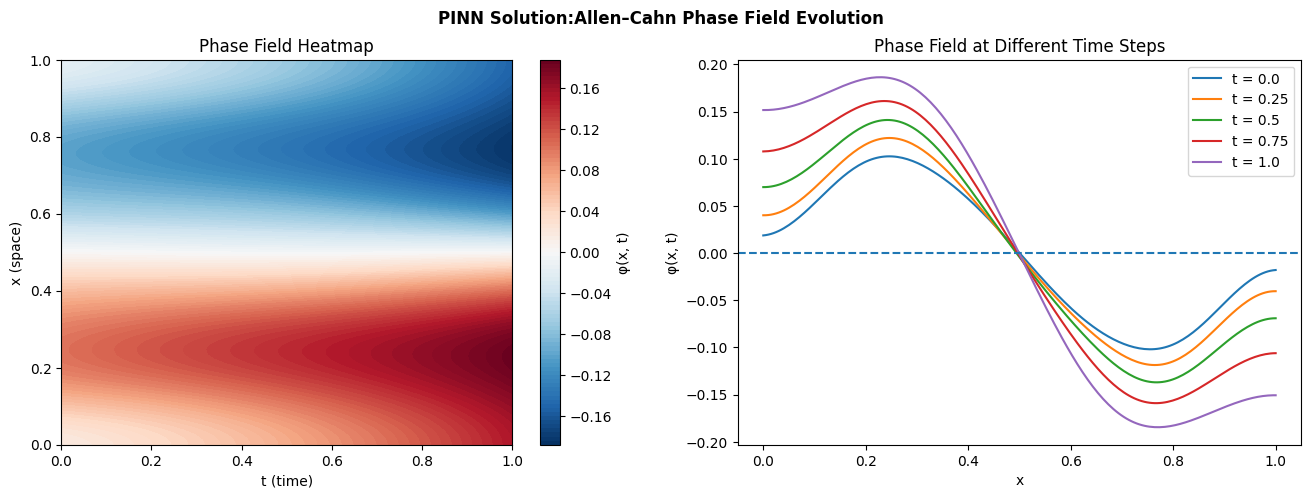

In [12]:
#heatmap 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("PINN Solution:Allen–Cahn Phase Field Evolution", fontweight='bold')

im = axes[0].contourf(t_vals.numpy(), x_vals.numpy(), phi_grid, 
                       levels=100, cmap='RdBu_r')
plt.colorbar(im, ax=axes[0], label='φ(x, t)')
axes[0].set_xlabel("t (time)")
axes[0].set_ylabel("x (space)")
axes[0].set_title("Phase Field Heatmap")

# time snapshots
for t_snap in [0.0, 0.25, 0.5, 0.75, 1.0]:
    t_idx = int(t_snap * (n_t - 1))
    axes[1].plot(x_vals.numpy(), phi_grid[:, t_idx], 
                 label=f't = {t_snap}')

axes[1].set_xlabel("x")
axes[1].set_ylabel("φ(x, t)")
axes[1].set_title("Phase Field at Different Time Steps")
axes[1].legend()
axes[1].axhline(0, linestyle='--')

plt.show()

The heatmap confirms the network has learned physically correct Allen–Cahn dynamics. 
The sin initial profile φ(x,0) is recovered. 
Also the phase field amplitude grows progressively over time (shown in time snapshots as curves moving away from zero). 


This is expected the perturbation wavenumber k=2π lies below the critical wavenumber k_c = 1/ε = 10, placing it in the unstable regime.
Here AC predicts amplification and eventual phase separation toward basically, φ = ±1.

## Now comparing this with standard finite difference method to solve PDE

Discretize domain into a fixed grid and move forward in time stepwise using the PDE directly. Thus no training or weights are needed. 

In FDM we use this approximation:
$$\frac{\partial^2 \phi}{\partial x^2}\Bigg|_i \approx \frac{\phi_{i+1} - 2\phi_i + \phi_{i-1}}{\Delta x^2}$$

In [17]:
def fdm_allen_cahn(nx=200, nt=5000, M=1.0, eps=0.1):
    x = np.linspace(0, 1, nx)  # setting up grid
    dx = x[1] - x[0]
    dt = 1.0/nt
    
    stability = (M*eps**2 * dt)/(dx**2)         #Stability check (small dt for explicit scheme)
    print(f"Stability number: {stability:.4f} (hopefully < 0.5)")  #If >0.5, the explicit scheme may become unstable, lead to divergent solutions (reduced dt to prevent this)
    
    phi=0.1*np.sin(2* (np.pi)*x)  #initial condition
    
    t_snapshots = [0.0, 0.25, 0.5, 0.75, 1.0]    # Saving at specific time snapshots
    phi_saved = {}
    phi_full=np.zeros((nx, nt+1))
    phi_full[:, 0] = phi.copy()
    
    for n in range(nt):     #Moving ahead in time 
        phi_new = phi.copy()
    
        # Interior points, basically central difference for Laplacian
        phi_xx = (np.roll(phi, -1) - 2*phi + np.roll(phi, 1)) / dx**2   #np.roll shifts the entire array
        #reference:     phi_{i+1}    phi_i        phi_{i-1}
        
        phi_new = phi + dt * M * (eps**2 * phi_xx - (phi**3 -  phi))   #AC update
        
        phi_new[0]  = phi_new[1]
        phi_new[-1] = phi_new[-2]
        phi = phi_new.copy()
        phi_full[:, n+1] = phi.copy()
        
        # Save snapshots
        t_current = (n+1) * dt
        for t_snap in t_snapshots:
            if abs(t_current - t_snap) < dt/2:
                phi_saved[t_snap] = phi.copy()
    
    return x, phi_full, phi_saved

In [18]:
#run FDM
x_fdm, phi_full_fdm, phi_saved_fdm = fdm_allen_cahn()
t_vals_fdm = np.linspace(0, 1, phi_full_fdm.shape[1])
print("FDM solver done")

Stability number: 0.0792 (hopefully < 0.5)
FDM solver done


THus the AC equation is discretized by using central difference approximation for the Laplacian and an explicit forward Euler scheme for time marching. 
Neumann boundary conditions are also enforced at the domain edges. 
FDM solver make a reliable ground truth for validation.


In [19]:
#Interpolating FDM solution onto PINN grid
from scipy.interpolate import RegularGridInterpolator 

x_pinn = np.linspace(0,1,200)
t_pinn =np.linspace(0,1,200)
t_fdm = np.linspace(0,1, phi_full_fdm.shape[1])

fdm_interp = RegularGridInterpolator(    #allows to estimate the FDM solution at any (x,t) point within the domain (also PINN gridpoints)
    (np.linspace(0, 1, 200),t_fdm),
    phi_full_fdm,
    method='linear'
)

# Query at PINN grid points
XX, TT =np.meshgrid(x_pinn, t_pinn, indexing='ij')
pts=np.stack([XX.ravel(), TT.ravel()], axis=1)
phi_fdm_grid = fdm_interp(pts).reshape(200, 200)

x_t = torch.tensor(XX.ravel(), dtype=torch.float32).unsqueeze(1)   #get predictions from trained model at same grid points as FDM 
t_t = torch.tensor(TT.ravel(), dtype=torch.float32).unsqueeze(1)

model.eval()
with torch.no_grad():
    phi_pinn_grid = model(x_t, t_t).numpy().reshape(200, 200)

In [20]:
#Calculating L2 Error
l2_error = np.linalg.norm(phi_pinn_grid -  phi_fdm_grid) / np.linalg.norm(phi_fdm_grid)
print(f"Relative L2 Error: {l2_error*100:.2f}%")      
#L2 error is used for the difference between two functions.
# Basically a root mean square distance btw 2 solutions acroos all points in domain.
# Relative L2 normalizes this by magnitude of true solution, kind off like a fractional error.

Relative L2 Error: 3.50%
